In [1]:
import sys
from pathlib import Path


ROOT = Path.cwd().resolve()
if (ROOT / 'src').exists():
    pass
elif (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
elif (ROOT.parent.parent / 'src').exists():
    ROOT = ROOT.parent.parent
sys.path.insert(0, str(ROOT))

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from surprise import Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split

from src.utils.cluster_simulation import generate_simulation
from src.utils.popularity import get_models


In [3]:
R_syn = generate_simulation()
rows, cols = np.where(~np.isnan(R_syn))
ratings_long = pd.DataFrame({"UserID": rows, "MovieID": cols, "Rating": R_syn[rows, cols].astype(float)})
ratings_long.head()
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_long[["UserID", "MovieID", "Rating"]], reader)
data


In [4]:
def evaluate_models_with_surprise(ratings_long, cv=5):
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(ratings_long[["UserID", "MovieID", "Rating"]], reader)

    rows = []
    for name, algo in get_models().items():
        try:
            cv_results = cross_validate(algo, data, measures=["RMSE"], cv=cv, verbose=False)
            rows.append({"Model": name, "RMSE": float(np.mean(cv_results["test_rmse"]))})
        except Exception:
            pass

    metrics_df = pd.DataFrame(rows)
    ref_rmse = metrics_df.loc[metrics_df["Model"] == "BaselineOnly", "RMSE"].iloc[0]
    metrics_df["Relative RMSE"] = metrics_df["RMSE"] / ref_rmse
    return metrics_df


mu_values = [-0.8, -0.4, 0.0, 0.4, 0.8]
rows = []

for mu in mu_values:
    R_syn = generate_simulation(mu=mu, seed=42)
    r, c = np.where(~np.isnan(R_syn))
    ratings_long = pd.DataFrame({"UserID": r, "MovieID": c, "Rating": R_syn[r, c].astype(float)})

    metrics_df = evaluate_models_with_surprise(ratings_long, cv=5)
    metrics_df["mu"] = mu
    rows.append(metrics_df)

mu_sweep_df = pd.concat(rows, ignore_index=True)
mu_sweep_df


,Model,RMSE,Relative RMSE,mu
0,BaselineOnly,0.681096,1.000000,-0.8
1,CF User-Pearson,0.772701,1.134497,-0.8
2,SVD,0.660283,0.969442,-0.8
3,SVDpp,0.641322,0.941604,-0.8
4,Random,1.365402,2.004713,-0.8
5,BaselineOnly,0.705880,1.000000,-0.4
6,CF User-Pearson,0.821526,1.163832,-0.4
7,SVD,0.682293,0.966585,-0.4
8,SVDpp,0.664436,0.941287,-0.4
9,Random,1.452815,2.058162,-0.4


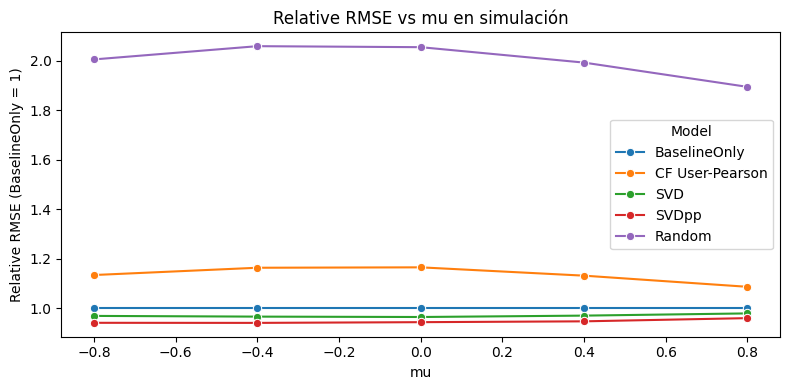

In [5]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=mu_sweep_df, x='mu', y='Relative RMSE', hue='Model', marker='o')
plt.title('Relative RMSE vs mu en simulación')
plt.xlabel('mu')
plt.ylabel('Relative RMSE (BaselineOnly = 1)')
plt.tight_layout()
plt.show()


In [6]:
alpha_values = [0.3, 0.9, 1.5]
rows = []

for alpha_user in alpha_values:
    for alpha_item in alpha_values:
        R_syn = generate_simulation(alpha_user=alpha_user, alpha_item=alpha_item)
        r, c = np.where(~np.isnan(R_syn))
        ratings_long = pd.DataFrame({"UserID": r, "MovieID": c, "Rating": R_syn[r, c].astype(float)})

        metrics_df = evaluate_models_with_surprise(ratings_long, cv=3)
        metrics_df["alpha_user"] = alpha_user
        metrics_df["alpha_item"] = alpha_item
        rows.append(metrics_df)

alpha_sweep_df = pd.concat(rows, ignore_index=True)
alpha_sweep_df


,Model,RMSE,Relative RMSE,alpha_user,alpha_item
0,BaselineOnly,0.669543,1.000000,0.3,0.3
1,CF User-Pearson,0.807609,1.206209,0.3,0.3
2,SVD,0.662872,0.990037,0.3,0.3
3,SVDpp,0.645458,0.964027,0.3,0.3
4,Random,1.354318,2.022749,0.3,0.3
5,BaselineOnly,0.673684,1.000000,0.3,0.9
6,CF User-Pearson,0.791087,1.174270,0.3,0.9
7,SVD,0.664195,0.985914,0.3,0.9
8,SVDpp,0.638535,0.947825,0.3,0.9
9,Random,1.361349,2.020753,0.3,0.9


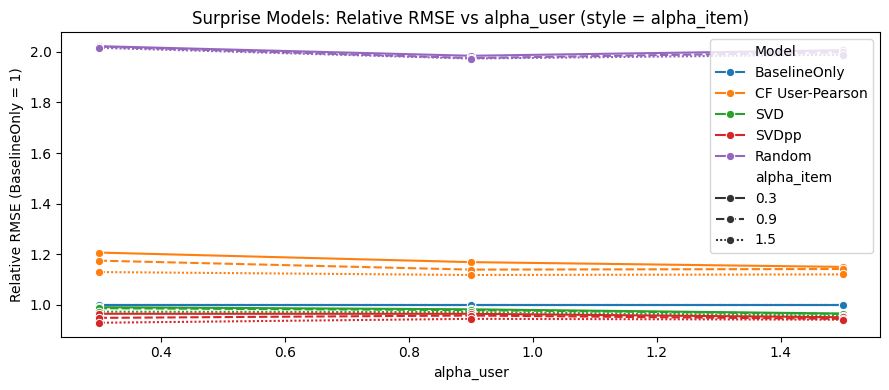

In [7]:
plt.figure(figsize=(9, 4))
sns.lineplot(
    data=alpha_sweep_df,
    x='alpha_user',
    y='Relative RMSE',
    hue='Model',
    style='alpha_item',
    marker='o',
)
plt.title('Surprise Models: Relative RMSE vs alpha_user (style = alpha_item)')
plt.xlabel('alpha_user')
plt.ylabel('Relative RMSE (BaselineOnly = 1)')
plt.tight_layout()
plt.show()


In [8]:
density_values = [0.01, 0.05, 0.1]
rows = []

for density in density_values:
    R_syn = generate_simulation(density=density, mu=0, seed=42)
    r, c = np.where(~np.isnan(R_syn))
    ratings_long = pd.DataFrame({"UserID": r, "MovieID": c, "Rating": R_syn[r, c].astype(float)})

    metrics_df = evaluate_models_with_surprise(ratings_long, cv=5)
    metrics_df["density"] = density
    rows.append(metrics_df)

density_sweep_df = pd.concat(rows, ignore_index=True)
density_sweep_df


,Model,RMSE,Relative RMSE,density
0,BaselineOnly,0.773771,1.000000,0.01
1,CF User-Pearson,0.919026,1.187723,0.01
2,SVD,0.753998,0.974446,0.01
3,SVDpp,0.732847,0.947111,0.01
4,Random,1.448059,1.871431,0.01
5,BaselineOnly,0.710247,1.000000,0.05
6,CF User-Pearson,0.825296,1.161984,0.05
7,SVD,0.689817,0.971235,0.05
8,SVDpp,0.674204,0.949253,0.05
9,Random,1.447072,2.037421,0.05


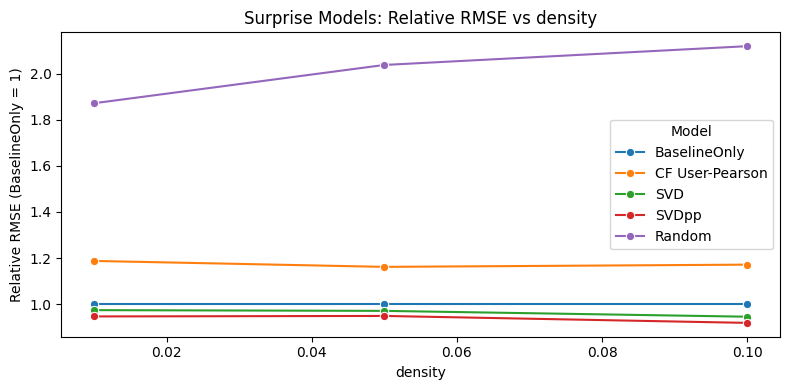

In [9]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=density_sweep_df, x='density', y='Relative RMSE', hue='Model', marker='o')
plt.title('Surprise Models: Relative RMSE vs density')
plt.xlabel('density')
plt.ylabel('Relative RMSE (BaselineOnly = 1)')
plt.tight_layout()
plt.show()
